# TEMPO L3 & L2

The Tropospheric Emissions: Monitoring of Pollution (TEMPO) products capture high-frequency air quality observations from a geostationary orbit over North America. Level-2 provides geolocated swath measurements at a few km resolution along the instrument’s scan, including trace gases such as NO₂, O₃, and HCHO, preserving the full spatial and temporal detail (hourly daytime coverage). Level-3 products aggregate these observations onto a regular latitude–longitude grid, reducing noise and filling gaps through spatial and temporal averaging (e.g., hourly or daily). 

This notebook will use these two products:

* TEMPO_NO2_L3 this is level 3 on a grid
* TEMPO_O3TOT_L2 this is level 2 swath data

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are fast. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [ ]:
# if needed
pip install point-collocation

In [ ]:
import earthaccess
earthaccess.login()

## TEMPO_NO2_L3

### Create some points

Random global and only over land in 2024.

In [1]:
import pandas as pd
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/point-collocation/main/"
    "examples/fixtures/points_1000_usa.csv"
)
df_points = pd.read_csv(
    url,
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == True)
]
print(len(df))
df.head()

28


,lat,lon,time,land
5,42.919232,-107.118997,2024-02-07 19:04:58,True
22,32.033815,-87.504205,2024-03-12 19:18:24,True
106,44.862977,-110.808178,2024-05-21 15:46:24,True
127,36.649735,-80.935069,2024-04-24 22:48:36,True
138,29.592103,-95.889008,2024-03-30 03:06:23,True


### Create the plan

In [2]:
%%time
import point_collocation as pc
short_name="TEMPO_NO2_L3"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "V03"
    },
    time_buffer="1h"
)
plan.summary(n=2)

Plan: 28 points → 30 unique granule(s)
  Points with 0 matches : 17
  Points with >1 matches: 10
  Time buffer: 0 days 01:00:00

First 2 point(s):
  [5] lat=42.9192, lon=-107.1190, time=2024-02-07 19:04:58: 3 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T172301Z_S007.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T182301Z_S008.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T192301Z_S009.nc
  [22] lat=32.0338, lon=-87.5042, time=2024-03-12 19:18:24: 2 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.03.12/TEMPO_NO2_L3_V03_20240312T174835Z_S009.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.03.12/TEMPO_NO2_L3_V03_20240312T184835Z_S010.nc
CPU times: use

### Look at the variables

We will open a file with datatree and see what groups it has (if any). It does have groups; the latitude, longitude is at the base level: `/` and the product is in `/product`. We want `vertical_column_troposphere` which is the NO2. So we create a profile for TEMPO. We open a dataset with the profile to make sure it looks good.

In [3]:
%%time
tempo = {
    'xarray_open': 'dataset',
    'merge': ['/', '/product'],
}
ds = plan.open_dataset(0, open_method=tempo)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/', '/product'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
Geolocation auto detected with cf_xarray: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',); time dim='time' (1 step(s))
Points columns used: y='lat', x='lon', time='time'
CPU times: user 2.03 s, sys: 417 ms, total: 2.44 s
Wall time: 6.98 s


<xarray.Dataset> Size: 732MB
Dimensions:                                  (latitude: 2950, longitude: 7750,
                                              time: 1)
Coordinates:
  * latitude                                 (latitude) float32 12kB 14.01 .....
  * longitude                                (longitude) float32 31kB -168.0 ...
  * time                                     (time) datetime64[ns] 8B 2024-01...
Data variables:
    weight                                   (latitude, longitude) float32 91MB dask.array<chunksize=(590, 1550), meta=np.ndarray>
    vertical_column_troposphere              (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    vertical_column_troposphere_uncertainty  (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    vertical_column_stratosphere             (time, latitude, longitude) float64 183MB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    main_data_quality_flag                   (time, latitude, longitude) float32 91MB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
Attributes: (12/40)
    history:                          2024-08-07T13:18:52Z: L2_regrid -v /tem...
    scan_num:                         1
    time_coverage_start:              2024-01-03T12:52:54Z
    time_coverage_end:                2024-01-03T13:32:40Z
    time_coverage_start_since_epoch:  1388321592.148252
    time_coverage_end_since_epoch:    1388323978.7368417
    ...                               ...
    title:                            TEMPO Level 3 nitrogen dioxide product
    collection_shortname:             TEMPO_NO2_L3
    collection_version:               1
    keywords:                         EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NI...
    summary:                          Nitrogen dioxide Level 3 files provide ...
    coremetadata:                     \nGROUP                  = INVENTORYMET...

In [4]:
%%time
res = pc.matchup(plan, 
                 variables = ["vertical_column_troposphere"], 
                 open_method=tempo)

CPU times: user 22.8 s, sys: 5.23 s, total: 28 s
Wall time: 2min 7s


In [5]:
# full res shows more info about matchups, like the granule lat lon
res[['lat', 'lon', 'time', 'vertical_column_troposphere']].dropna(subset=['vertical_column_troposphere']).head()

,lat,lon,time,vertical_column_troposphere
0,42.919232,-107.118997,2024-02-07 19:04:58,8.827827e+14
1,42.919232,-107.118997,2024-02-07 19:04:58,6.472115e+14
2,42.919232,-107.118997,2024-02-07 19:04:58,1.072898e+15
3,32.033815,-87.504205,2024-03-12 19:18:24,2.557054e+15
4,32.033815,-87.504205,2024-03-12 19:18:24,2.620639e+14


### Plot our points with data

In [6]:
ds = plan.open_dataset(2, open_method=tempo)

open_method: {'xarray_open': 'dataset', 'merge': ['/', '/product'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
Geolocation auto detected with cf_xarray: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',); time dim='time' (1 step(s))
Points columns used: y='lat', x='lon', time='time'


In [19]:
ds["vertical_column_troposphere"].units

'molecules/cm^2'

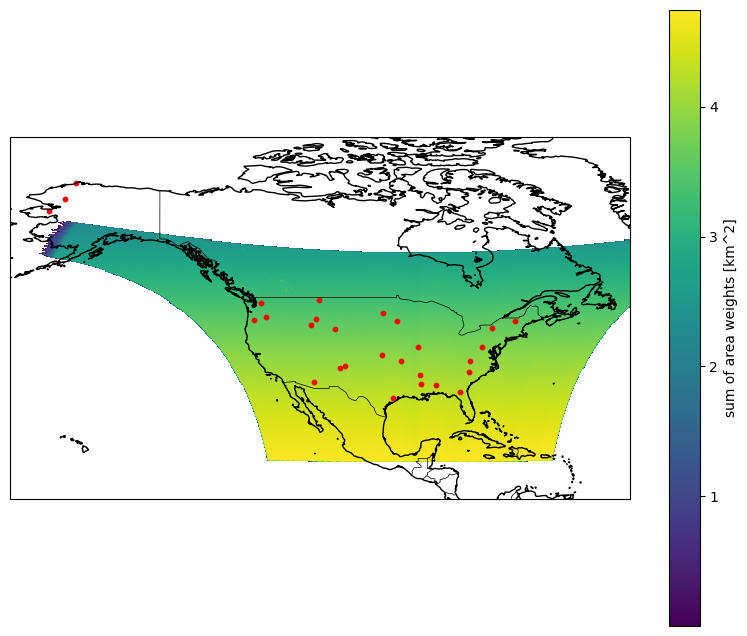

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ds_plot = ds.weight.coarsen(latitude=10, longitude=10, boundary="trim").mean()

ax = plt.axes(projection=ccrs.PlateCarree())

# plot xarray field
ds_plot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    add_colorbar=True
)

# coastlines
ax.coastlines(resolution="50m", linewidth=1)

# optional: borders
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# plot dataframe points
ax.scatter(
    df["lon"],
    df["lat"],
    color="red",
    s=10,
    transform=ccrs.PlateCarree(),
    label="points"
)

# zoom to North America
ax.set_extent([-170, -50, 10, 80], crs=ccrs.PlateCarree())

plt.show()

## TEMPO_O3TOT_L2

This is level 2 swath data. Let's take a look at how to get some matchups. The granule planning takes awhile so let's start with a few points.

In [8]:
import pandas as pd
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/point-collocation/main/"
    "examples/fixtures/points_1000_usa.csv"
)
df_points = pd.read_csv(
    url,
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == True) &
    (df_points["lon"] < -60) &
    (df_points["lon"] > -100)
    
]
print(len(df))
df.head()

15


,lat,lon,time,land
22,32.033815,-87.504205,2024-03-12 19:18:24,True
127,36.649735,-80.935069,2024-04-24 22:48:36,True
138,29.592103,-95.889008,2024-03-30 03:06:23,True
159,37.789200,-98.045855,2024-01-26 18:04:05,True
161,44.349757,-72.301856,2024-06-13 10:50:15,True


### Get the plan

In [9]:
%%time
import point_collocation as pc
short_name="TEMPO_O3TOT_L2"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "V03"
    },
    time_buffer="1h"
)
plan.summary(n=1)

Plan: 15 points → 12 unique granule(s)
  Points with 0 matches : 9
  Points with >1 matches: 4
  Time buffer: 0 days 01:00:00

First 1 point(s):
  [22] lat=32.0338, lon=-87.5042, time=2024-03-12 19:18:24: 1 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_O3TOT_L2_V03/2024.03.12/TEMPO_O3TOT_L2_V03_20240312T190833Z_S010G04.nc
CPU times: user 2.68 s, sys: 251 ms, total: 2.93 s
Wall time: 25.7 s


### Take a look at the granules

These are grouped netcdfs and we need to figure out what groups we need and variable names.

In [10]:
ds = plan.open_dataset(0, open_method="datatree")
ds

open_method: {'xarray_open': 'datatree', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'merge': None, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}
Geolocation: DataTree returned without merging — no geolocation summary.


<xarray.DataTree>
Group: /
│   Dimensions:      (xtrack: 2048, mirror_step: 131)
│   Coordinates:
│     * xtrack       (xtrack) int32 8kB 0 1 2 3 4 5 ... 2043 2044 2045 2046 2047
│     * mirror_step  (mirror_step) int32 524B 132 133 134 135 ... 259 260 261 262
│   Attributes: (12/34)
│       time_reference:                   1980-01-06T00:00:00Z
│       scan_num:                         1
│       granule_num:                      2
│       time_coverage_start:              2024-01-03T12:59:34Z
│       time_coverage_end:                2024-01-03T13:06:11Z
│       time_coverage_start_since_epoch:  1388321992.512726
│       ...                               ...
│       title:                            TEMPO Level 2 total ozone product
│       collection_shortname:             TEMPO_O3TOT_L2
│       collection_version:               1
│       keywords:                         EARTH SCIENCE>ATMOSPHERE>ATMOSPHERIC CH...
│       summary:                          Total ozone Level 2 files provide ozone...
│       coremetadata:                     \nGROUP                  = INVENTORYMET...
├── Group: /product
│       Dimensions:               (mirror_step: 131, xtrack: 2048)
│       Data variables:
│           column_amount_o3      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           radiative_cloud_frac  (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           fc                    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           quality_flag          (mirror_step, xtrack) int32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           o3_below_cloud        (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           so2_index             (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           uv_aerosol_index      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
├── Group: /geolocation
│       Dimensions:                 (mirror_step: 131, xtrack: 2048, corner: 4)
│       Coordinates:
│           time                    (mirror_step) datetime64[ns] 1kB dask.array<chunksize=(131,), meta=np.ndarray>
│           latitude                (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           longitude               (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│       Dimensions without coordinates: corner
│       Data variables:
│           latitude_bounds         (mirror_step, xtrack, corner) float32 4MB dask.array<chunksize=(131, 2048, 4), meta=np.ndarray>
│           longitude_bounds        (mirror_step, xtrack, corner) float32 4MB dask.array<chunksize=(131, 2048, 4), meta=np.ndarray>
│           solar_zenith_angle      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           solar_azimuth_angle     (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           viewing_zenith_angle    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           viewing_azimuth_angle   (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           relative_azimuth_angle  (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
├── Group: /support_data
│       Dimensions:                        (mirror_step: 131, xtrack: 2048,
│                                           wavelength: 12, layer: 11)
│       Dimensions without coordinates: wavelength, layer
│       Data variables: (12/21)
│           ground_pixel_quality_flag      (mirror_step, xtrack) int32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           lut_wavelength                 (wavelength) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
│           cloud_pressure         

### Ok now we know the groups

We will make a open_method dictionary.

In [11]:
tempo_l2 = {
    'xarray_open': 'dataset',
    'merge': ['/product', '/geolocation'],
    'coords': {'lat': 'latitude', 'lon': 'longitude'},
}
ds = plan.open_dataset(0, open_method=tempo_l2)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/product', '/geolocation'], 'coords': {'lat': 'latitude', 'lon': 'longitude'}, 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
Geolocation specified: ('longitude', 'latitude') — lon dims=('mirror_step', 'xtrack'), lat dims=('mirror_step', 'xtrack')
Points columns used: y='lat', x='lon', time='time'


<xarray.Dataset> Size: 24MB
Dimensions:                 (mirror_step: 131, xtrack: 2048, corner: 4)
Coordinates:
    time                    (mirror_step) datetime64[ns] 1kB dask.array<chunksize=(131,), meta=np.ndarray>
    latitude                (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    longitude               (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
Dimensions without coordinates: mirror_step, xtrack, corner
Data variables: (12/14)
    column_amount_o3        (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    radiative_cloud_frac    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    fc                      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    quality_flag            (mirror_step, xtrack) int32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    o3_below_cloud          (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    so2_index               (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    ...                      ...
    longitude_bounds        (mirror_step, xtrack, corner) float32 4MB dask.array<chunksize=(131, 2048, 4), meta=np.ndarray>
    solar_zenith_angle      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    solar_azimuth_angle     (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    viewing_zenith_angle    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    viewing_azimuth_angle   (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    relative_azimuth_angle  (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>

### Now we get the matchups using this open_method dict

It is roughly 2 seconds per point. So roughly 5 hrs for 10,000 points.

In [12]:
%%time
res = pc.matchup(plan, 
                 variables = ["uv_aerosol_index"], 
                 open_method=tempo_l2)

CPU times: user 10.1 s, sys: 691 ms, total: 10.8 s
Wall time: 25.5 s


In [13]:
(
    res[['lat', 'lon', 'time', 'uv_aerosol_index']]
        .dropna(subset=['uv_aerosol_index'])
)

,lat,lon,time,uv_aerosol_index
0,32.033815,-87.504205,2024-03-12 19:18:24,-2.219414
1,36.649735,-80.935069,2024-04-24 22:48:36,-2.591015
4,44.349757,-72.301856,2024-06-13 10:50:15,-1.152082
5,44.349757,-72.301856,2024-06-13 10:50:15,-1.889225
6,44.355987,-95.126999,2024-01-14 16:55:19,-2.514838
7,44.355987,-95.126999,2024-01-14 16:55:19,-2.738163
9,34.035328,-90.559024,2024-07-31 23:17:20,-2.717468
10,34.035328,-90.559024,2024-07-31 23:17:20,-2.282551
11,34.035328,-90.559024,2024-07-31 23:17:20,-1.936824
17,45.961109,-97.761663,2024-07-01 12:06:54,-1.305435


### Here is a plot showing points and swaths

This is just one swath. The matchup routine finds the granules matching each point.

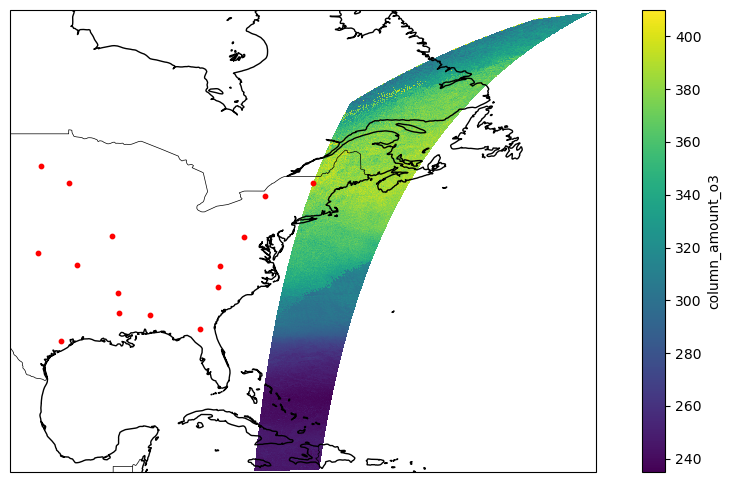

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

var = ds["column_amount_o3"]

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    var,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# plot dataframe points
ax.scatter(
    df["lon"],
    df["lat"],
    color="red",
    s=10,
    transform=ccrs.PlateCarree(),
    label="points"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(pcm, ax=ax, label=var.name)
plt.show()